In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import random

DATASET_PATH = r"Novi Dataset\patches_8000_random"
MODEL_SAVE_PATH = "SavedModels"
MODEL_NAME = "PatchesRandom8000_PointNet2.pth"
EPOCHS = 100
PATIENCE = 10
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
BATCH_SIZE = 4

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"Training PointNet++ on RANDOM PATCHES on: {DEVICE}")
print(f"Dataset: {DATASET_PATH} | Seed: {SEED}")

Training PointNet++ on RANDOM PATCHES on: cuda
Dataset: Novi Dataset\patches_8000_random | Seed: 42


In [2]:
class PatchDataset(Dataset):
    def __init__(self, file_paths, augment=False):
        self.file_paths = file_paths
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = np.load(file_path, allow_pickle=True).item()
        points = data['points'].astype(np.float32)
        colors = data['colors'].astype(np.float32)
        labels = data['labels'].astype(np.int64)
        if colors.max() > 1.0:
            colors = colors / 255.0

        if self.augment:
            angle = np.random.uniform(0, 2 * np.pi)
            cos_a, sin_a = np.cos(angle), np.sin(angle)
            rot = np.array([[cos_a, -sin_a, 0],
                            [sin_a,  cos_a, 0],
                            [0,      0,     1]], dtype=np.float32)
            points = points @ rot.T
            points += np.random.randn(*points.shape).astype(np.float32) * 0.005

        features = np.concatenate([points, colors], axis=1)   # (8000, 6)
        return (
            torch.tensor(features, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
            file_path
        )

In [3]:
def square_distance(src, dst):
    B, N, _ = src.shape
    _, M, _ = dst.shape
    dist = -2 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, -1).view(B, N, 1)
    dist += torch.sum(dst ** 2, -1).view(B, 1, M)
    return dist

def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    return points[batch_indices, idx, :]

def farthest_point_sample(xyz, npoint):
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.zeros(B, dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        distance = torch.min(distance, dist)
        farthest = torch.max(distance, -1)[1]
    return centroids

def query_ball_point(radius, nsample, xyz, new_xyz):
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long).to(device).view(1, 1, N).repeat([B, S, 1])
    sqrdists = square_distance(new_xyz, xyz)
    group_idx[sqrdists > radius ** 2] = N
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat([1, 1, nsample])
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx

def sample_and_group(npoint, radius, nsample, xyz, points):
    B, N, C = xyz.shape
    new_xyz = index_points(xyz, farthest_point_sample(xyz, npoint))
    idx = query_ball_point(radius, nsample, xyz, new_xyz)
    grouped_xyz = index_points(xyz, idx)
    grouped_xyz_norm = grouped_xyz - new_xyz.view(B, npoint, 1, C)
    if points is not None:
        grouped_points = index_points(points, idx)
        new_points = torch.cat([grouped_xyz_norm, grouped_points], dim=-1)
    else:
        new_points = grouped_xyz_norm
    return new_xyz, new_points

def sample_and_group_all(xyz, points):
    device = xyz.device
    B, N, C = xyz.shape
    new_xyz = torch.zeros(B, 1, C).to(device)
    grouped_xyz = xyz.view(B, 1, N, C)
    if points is not None:
        new_points = torch.cat([grouped_xyz, points.view(B, 1, N, -1)], dim=-1)
    else:
        new_points = grouped_xyz
    return new_xyz, new_points

class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp):
        super().__init__()
        self.npoint = npoint
        self.radius = radius
        self.nsample = nsample
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns   = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv2d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm2d(out_channel))
            last_channel = out_channel

    def forward(self, xyz, points):
        if self.npoint is not None:
            new_xyz, new_points = sample_and_group(self.npoint, self.radius, self.nsample, xyz, points)
        else:
            new_xyz, new_points = sample_and_group_all(xyz, points)
        new_points = new_points.permute(0, 3, 2, 1)
        for i, conv in enumerate(self.mlp_convs):
            new_points = F.relu(self.mlp_bns[i](conv(new_points)))
        new_points = torch.max(new_points, 2)[0].transpose(1, 2)
        return new_xyz, new_points

class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super().__init__()
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns   = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv1d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm1d(out_channel))
            last_channel = out_channel

    def forward(self, xyz1, xyz2, points1, points2):
        B, N, C = xyz1.shape
        _, S, _ = xyz2.shape
        if S == 1:
            interpolated_points = points2.repeat(1, N, 1)
        else:
            dists = square_distance(xyz1, xyz2)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dists + 1e-8)
            norm = torch.sum(dist_recip, dim=2, keepdim=True)
            weight = dist_recip / norm
            interpolated_points = torch.sum(index_points(points2, idx) * weight.view(B, N, 3, 1), dim=2)
        if points1 is not None:
            new_points = torch.cat([points1, interpolated_points], dim=-1)
        else:
            new_points = interpolated_points
        new_points = new_points.permute(0, 2, 1)
        for i, conv in enumerate(self.mlp_convs):
            new_points = F.relu(self.mlp_bns[i](conv(new_points)))
        return new_points.permute(0, 2, 1)


class PointNetPPRGBSegmentation(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.sa1 = PointNetSetAbstraction(256, 0.2, 32, 9,           [32, 32, 64])
        self.sa2 = PointNetSetAbstraction(64,  0.4, 32, 64 + 3,      [64, 64, 128])
        self.sa3 = PointNetSetAbstraction(None, None, None, 128 + 3,  [128, 256, 1024])

        self.fp3 = PointNetFeaturePropagation(1024 + 128, [256, 256])
        self.fp2 = PointNetFeaturePropagation(256 + 64,   [256, 128])
        self.fp1 = PointNetFeaturePropagation(128,        [128, 128, 128])

        self.conv1 = nn.Conv1d(128, 128, 1)
        self.bn1   = nn.BatchNorm1d(128)
        self.drop  = nn.Dropout(0.5)
        self.conv2 = nn.Conv1d(128, num_classes, 1)

    def forward(self, xyzrgb):
        l0_xyz    = xyzrgb[:, :, :3]
        l0_points = xyzrgb

        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)

        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        l0_points = self.fp1(l0_xyz, l1_xyz, None,      l1_points)

        x = l0_points.permute(0, 2, 1)
        x = self.drop(F.relu(self.bn1(self.conv1(x))))
        x = self.conv2(x)
        return x

In [4]:
patch_pattern = os.path.join(DATASET_PATH, "tree_*", "*", "*.npy")
all_patch_files = glob.glob(patch_pattern)
print(f"Ukupno patcheva: {len(all_patch_files)}")

def get_tree_name(fp):
    return fp.split(os.sep)[-3]

unique_trees = sorted(list(set(get_tree_name(f) for f in all_patch_files)))
train_trees, test_trees = train_test_split(unique_trees, test_size=0.15, random_state=42)
train_trees, val_trees  = train_test_split(train_trees,  test_size=0.18, random_state=42)
train_trees, val_trees, test_trees = set(train_trees), set(val_trees), set(test_trees)

train_paths = [f for f in all_patch_files if get_tree_name(f) in train_trees]
val_paths   = [f for f in all_patch_files if get_tree_name(f) in val_trees]
test_paths  = [f for f in all_patch_files if get_tree_name(f) in test_trees]

train_dataset = PatchDataset(train_paths, augment=True)
val_dataset   = PatchDataset(val_paths,   augment=False)
test_dataset  = PatchDataset(test_paths,  augment=False)

generator_treninga = torch.Generator()
generator_treninga.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=generator_treninga)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=0)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Ukupno patcheva: 8107
Train: 5460 | Val: 1491 | Test: 1156


Ucestalost klasa: {0: 5401212, 1: 26009071, 2: 5546295, 3: 6723422}
Auto alpha: ['2.022', '0.420', '1.969', '1.624']


Epoch 1/100: 100%|██████████| 1365/1365 [02:48<00:00,  8.09it/s, Loss=0.3936]


Epoch [1/100] -> Loss: 0.4221, Train Acc: 0.5108, Val Acc: 0.5180 | Time: 217.5s
--- Best model saved (Val Acc: 0.5180) ---


Epoch 2/100: 100%|██████████| 1365/1365 [02:47<00:00,  8.14it/s, Loss=0.2500]


Epoch [2/100] -> Loss: 0.3203, Train Acc: 0.6646, Val Acc: 0.6925 | Time: 204.1s
--- Best model saved (Val Acc: 0.6925) ---


...

Epoch [28/100] -> Loss: 0.1174, Train Acc: 0.9218, Val Acc: 0.9102 | Time: 203.8s
--- No improvement: 8/10 ---


Epoch 29/100: 100%|██████████| 1365/1365 [02:47<00:00,  8.14it/s, Loss=0.0845]


Epoch [29/100] -> Loss: 0.1158, Train Acc: 0.9240, Val Acc: 0.9103 | Time: 203.9s
--- No improvement: 9/10 ---


Epoch 30/100: 100%|██████████| 1365/1365 [02:46<00:00,  8.18it/s, Loss=0.1268]


Epoch [30/100] -> Loss: 0.1140, Train Acc: 0.9249, Val Acc: 0.9022 | Time: 203.6s
--- No improvement: 10/10 ---
Early stopping triggered after 30 epochs. Best Val Acc: 0.9163

Ukupno vrijeme treninga: 01:42:16


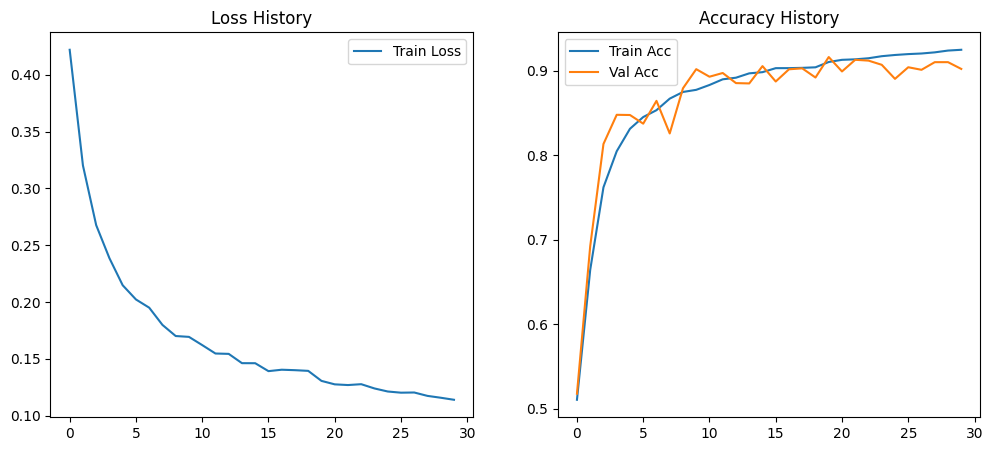

In [5]:
set_seed(SEED)

model = PointNetPPRGBSegmentation(num_classes=4).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([float(alpha)] * NUM_CLASSES)
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float32)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            at = alpha[targets]
            focal_loss = at * (1 - pt) ** self.gamma * ce_loss
        else:
            focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_flat(probas, labels, classes='present'):
    if probas.numel() == 0:
        return probas * 0.0
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = (labels == c).float()
        if classes == 'present' and fg.sum() == 0:
            continue
        class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    if len(losses) == 0:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()

class LovaszSoftmaxLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, inputs, targets):
        probas = F.softmax(inputs, dim=1)
        B, C, N = probas.shape
        probas = probas.permute(0, 2, 1).reshape(-1, C)
        targets = targets.reshape(-1)
        return lovasz_softmax_flat(probas, targets)


from collections import Counter
brojac = Counter()
for fp in train_paths:
    d = np.load(fp, allow_pickle=True).item()
    lbls = np.array(d['labels'], dtype=np.int64)
    for c in range(NUM_CLASSES):
        brojac[c] += int(np.sum(lbls == c))

ukupno = sum(brojac.values())
alpha_auto = [ukupno / (NUM_CLASSES * brojac[c]) if brojac[c] > 0 else 0.0 for c in range(NUM_CLASSES)]
print("Ucestalost klasa:", dict(brojac))
print("Auto alpha:", [f"{a:.3f}" for a in alpha_auto])

criterion = FocalLoss(alpha=alpha_auto, gamma=2.0)
lovasz = LovaszSoftmaxLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accs, val_accs = [], [], []
best_val_acc = 0.0
patience = PATIENCE
epochs_no_improve = 0

training_start = time.time()

try:
    for epoch in range(EPOCHS):
        epoch_start = time.time()
        model.train()
        epoch_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for features, labels, _ in pbar:
            features, labels = features.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(features)
            loss = 0.5 * criterion(outputs, labels) + 0.5 * lovasz(outputs, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.numel()

            pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for features, labels, _ in val_loader:
                features, labels = features.to(DEVICE), labels.to(DEVICE)
                outputs = model(features)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()

        val_acc = val_correct / val_total if val_total > 0 else 0
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start
        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, MODEL_NAME))
            print(f"--- Best model saved (Val Acc: {val_acc:.4f}) ---")
        else:
            epochs_no_improve += 1
            print(f"--- No improvement: {epochs_no_improve}/{patience} ---")
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs. Best Val Acc: {best_val_acc:.4f}")
                break

except KeyboardInterrupt:
    print(f"\nTrening prekinut. Najbolji Val Acc: {best_val_acc:.4f}")

total_time = time.time() - training_start
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nUkupno vrijeme treninga: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss History')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

In [6]:
import open3d as o3d
import time
from collections import defaultdict

MODEL_PATH = os.path.join("SavedModels", "PatchesRandom8000_PointNet2.pth")
model = PointNetPPRGBSegmentation(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from: {MODEL_PATH}")

KLASE = {0: "deblo", 1: "grane", 2: "potpora", 3: "trava"}

def predict_logits(model, features, device):
    x = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x)
    return out.squeeze(0).permute(1, 0).cpu().numpy()

oblaci = defaultdict(list)
for fp in test_paths:
    tree = fp.split(os.sep)[-3]
    cloud = fp.split(os.sep)[-2]
    oblaci[(tree, cloud)].append(fp)
print(f"Test oblaka: {len(oblaci)}")

conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
oblak_rezultati = []
inference_times = []

for (tree, cloud), patch_files in tqdm(oblaci.items(), desc="Rekonstrukcija po oblaku"):
    p0 = np.load(patch_files[0], allow_pickle=True).item()
    N = int(p0['n_original'])
    logit_sum = np.zeros((N, NUM_CLASSES), dtype=np.float64)
    logit_cnt = np.zeros(N, dtype=np.int64)
    prave_lbl = np.full(N, -1, dtype=np.int64)
    orig_points = np.zeros((N, 3), dtype=np.float64)
    orig_colors = np.zeros((N, 3), dtype=np.float64)

    t0 = time.perf_counter()
    for fp in patch_files:
        p = np.load(fp, allow_pickle=True).item()
        oi = p['orig_idx']
        points = p['points'].astype(np.float32)
        colors = p['colors'].astype(np.float32)
        cols_norm = colors / 255.0 if colors.max() > 1.0 else colors
        features = np.concatenate([points, cols_norm], axis=1)
        logits = predict_logits(model, features, DEVICE)
        logit_sum[oi] += logits
        logit_cnt[oi] += 1
        prave_lbl[oi] = p['labels']
        orig_points[oi] = points
        orig_colors[oi] = cols_norm
    inference_times.append(time.perf_counter() - t0)

    valid = logit_cnt > 0
    logit_avg = logit_sum[valid] / logit_cnt[valid, None]
    pred = np.argmax(logit_avg, axis=1)
    prave = prave_lbl[valid]
    for t, pr in zip(prave, pred):
        conf[t, pr] += 1

    ious = []
    for c in range(NUM_CLASSES):
        tp = np.sum((pred == c) & (prave == c))
        fp_ = np.sum((pred == c) & (prave != c))
        fn = np.sum((pred != c) & (prave == c))
        if np.sum(prave == c) > 0:
            ious.append(tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 1.0)
    miou = np.mean(ious) if ious else 0.0

    oblak_rezultati.append({
        'tree': tree, 'cloud': cloud, 'miou': miou,
        'points': orig_points[valid], 'colors': orig_colors[valid],
        'labels': prave, 'preds': pred,
        'pokriveno': int(valid.sum()), 'ukupno': N
    })

total_points = conf.sum()
accuracy = np.trace(conf) / total_points if total_points > 0 else 0
per_class_iou, per_class_prec, per_class_rec = {}, {}, {}
for c in range(NUM_CLASSES):
    tp = conf[c, c]
    fp_ = conf[:, c].sum() - tp
    fn = conf[c, :].sum() - tp
    per_class_iou[c]  = tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 0
    per_class_prec[c] = tp / (tp + fp_) if (tp + fp_) > 0 else 0
    per_class_rec[c]  = tp / (tp + fn) if (tp + fn) > 0 else 0
mean_iou = np.mean(list(per_class_iou.values()))

print("\n" + "="*50)
print("FINAL TEST METRICS: RANDOM PATCHES PointNet++ (rekonstruirano stablo)")
print("="*50)
print(f"Total Points: {total_points:,}")
print(f"Accuracy: {accuracy:.4f}")
print("-"*50)
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10} | IoU: {per_class_iou[c]:.4f} | Prec: {per_class_prec[c]:.4f} | Recall: {per_class_rec[c]:.4f}")
print("-"*50)
print(f"mIoU: {mean_iou:.4f}")
print("="*50)
print("\nConfusion [redak=stvarno, stupac=predvidjeno]:")
print(f"{'':<10}" + "".join(f"{KLASE[c]:<10}" for c in range(NUM_CLASSES)))
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10}" + "".join(f"{conf[c, p]:<10}" for p in range(NUM_CLASSES)))

svi_pokriveni = all(r['pokriveno'] == r['ukupno'] for r in oblak_rezultati)
print(f"\nRekonstrukcija egzaktna? {'DA' if svi_pokriveni else 'NE'}")
print(f"Prosjecno vrijeme po stablu: {np.mean(inference_times):.3f}s")
print("="*50)

PALETTE = {0: [0.0, 0.0, 1.0], 1: [0.0, 0.8, 0.0], 2: [1.0, 0.0, 0.0], 3: [0.6, 0.6, 0.6]}
def boji_po_klasi(labels):
    c = np.zeros((len(labels), 3))
    for k, col in PALETTE.items():
        c[labels == k] = col
    return c

oblak_rezultati.sort(key=lambda x: x['miou'])
worst, best = oblak_rezultati[0], oblak_rezultati[-1]
for tag, rez in [("WORST", worst), ("BEST", best)]:
    print(f"\n[{tag}] {rez['tree']}/{rez['cloud']} | mIoU: {rez['miou']:.4f}")
    pts = rez['points']
    for col, naslov in [(rez['colors'], "ORIGINAL RGB"),
                        (boji_po_klasi(rez['labels']), "LABELE"),
                        (boji_po_klasi(rez['preds']), "PREDIKCIJA")]:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.colors = o3d.utility.Vector3dVector(col)
        o3d.visualization.draw_geometries([pcd], window_name=f"{tag} {naslov} | mIoU {rez['miou']:.3f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Model loaded from: SavedModels\PatchesRandom8000_PointNet2.pth
Test oblaka: 92


Rekonstrukcija po oblaku: 100%|██████████| 92/92 [01:58<00:00,  1.29s/it]



FINAL TEST METRICS: RANDOM PATCHES PointNet++ (rekonstruirano stablo)
Total Points: 8,865,711
Accuracy: 0.9223
--------------------------------------------------
deblo      | IoU: 0.5377 | Prec: 0.6246 | Recall: 0.7944
grane      | IoU: 0.8914 | Prec: 0.9655 | Recall: 0.9207
potpora    | IoU: 0.8659 | Prec: 0.9177 | Recall: 0.9388
trava      | IoU: 0.9984 | Prec: 0.9986 | Recall: 0.9998
--------------------------------------------------
mIoU: 0.8233

Confusion [redak=stvarno, stupac=predvidjeno]:
          deblo     grane     potpora   trava     
deblo     732165    174082    15246     123       
grane     414702    5312373   41667     1325      
potpora   25347     15368     634927    696       
trava     34        195       0         1497461   

Rekonstrukcija egzaktna? DA
Prosjecno vrijeme po stablu: 1.222s

[WORST] tree_1_V_0178/18 | mIoU: 0.4723

[BEST] tree_1_V_0178/20 | mIoU: 0.9722
